# Segmentacja Klientow Bankowych - zadanie nr 1

---

## Zbior danych

Plik `bank_segmentation.csv` zawiera dane 800 klientow banku:

| Zmienna | Opis |
|---|---|
| monthly_income | Miesieczny dochod netto (PLN) |
| account_balance | Srednie saldo konta (PLN) |
| num_products | Liczba posiadanych produktow bankowych |
| mobile_logins_monthly | Liczba logowan przez aplikacje mobilna / miesiac |
| monthly_transactions | Liczba transakcji / miesiac |
| loan_to_income_ratio | Wskaznik zadluzenia do dochodu |
| savings_rate | Stopa oszczedzania (czesc dochodu odkладana miesiecznie) |
| age | Wiek klienta |
| gender | Plec |
| city_size | Wielkosc miejscowosci (duze / srednie / male) |

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.image as mpimg
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import kruskal, mannwhitneyu, chi2_contingency, pointbiserialr
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, silhouette_samples
)
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

PALETTE = ['#2196F3', '#E53935', '#43A047', '#8E24AA', '#FB8C00', '#FFC107', '#00BCD4', '#795548']

## Zadanie 1 - Przygotowanie i eksploracja danych

Wczytaj zbior, zapoznaj sie z jego struktura i przeprowadz eksploracje.
Zdecyduj, ktore zmienne powinny wchodzic do algorytmu grupowania,
a ktore pelniac role opisowa - i uzasadnij ten wybor.
Oblicz statystyki opisowe i zwizualizuj rozklady zmiennych segmentacyjnych.
Zbadaj korelacje miedzy zmiennymi i przeprowadz standaryzacje.

1. Struktura danych
Pierwsze 5 wierszy danych:
   client_id  monthly_income  account_balance  num_products  \
0          1            4074             9010             2   
1          2            2085             7537             1   
2          3            3858             2734             1   
3          4            6638             2373             2   
4          5            4029             2693             2   

   mobile_logins_monthly  monthly_transactions  loan_to_income_ratio  \
0                      6                    12                 0.019   
1                      3                    10                 0.064   
2                     22                    55                 0.057   
3                     18                    28                 0.646   
4                     25                    57                 0.128   

   savings_rate  age gender city_size  
0         0.143   54      M   srednie  
1         0.235   68      F      duze  
2         0.072   26 

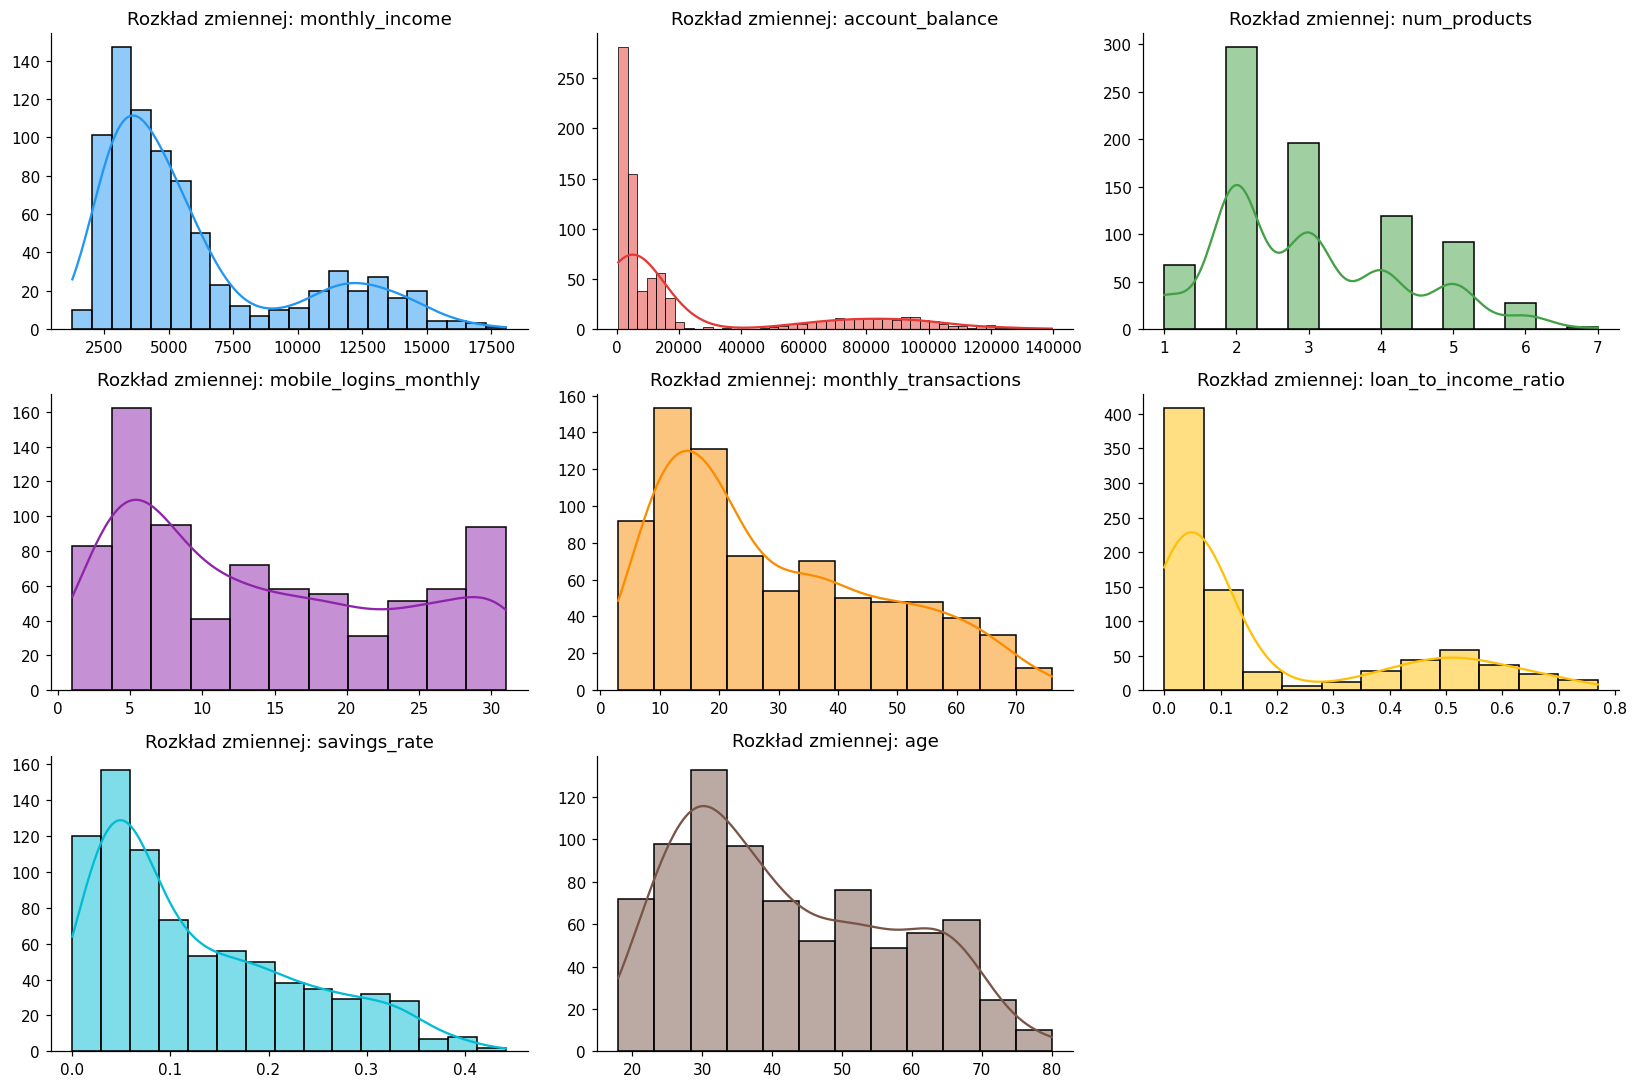

4. Korelacje między zmiennymi segmentacyjnymi 
Macierz korelacji dla zmiennych segmentacyjnych:
                       monthly_income  account_balance  num_products  \
monthly_income               1.000000         0.846535      0.805865   
account_balance              0.846535         1.000000      0.709588   
num_products                 0.805865         0.709588      1.000000   
mobile_logins_monthly       -0.232925        -0.427863     -0.180812   
monthly_transactions        -0.217682        -0.396366     -0.161835   
loan_to_income_ratio        -0.068311        -0.363738      0.077845   
savings_rate                 0.624185         0.812307      0.481752   
age                         -0.026138         0.221220     -0.078653   

                       mobile_logins_monthly  monthly_transactions  \
monthly_income                     -0.232925             -0.217682   
account_balance                    -0.427863             -0.396366   
num_products                       -0.180812 

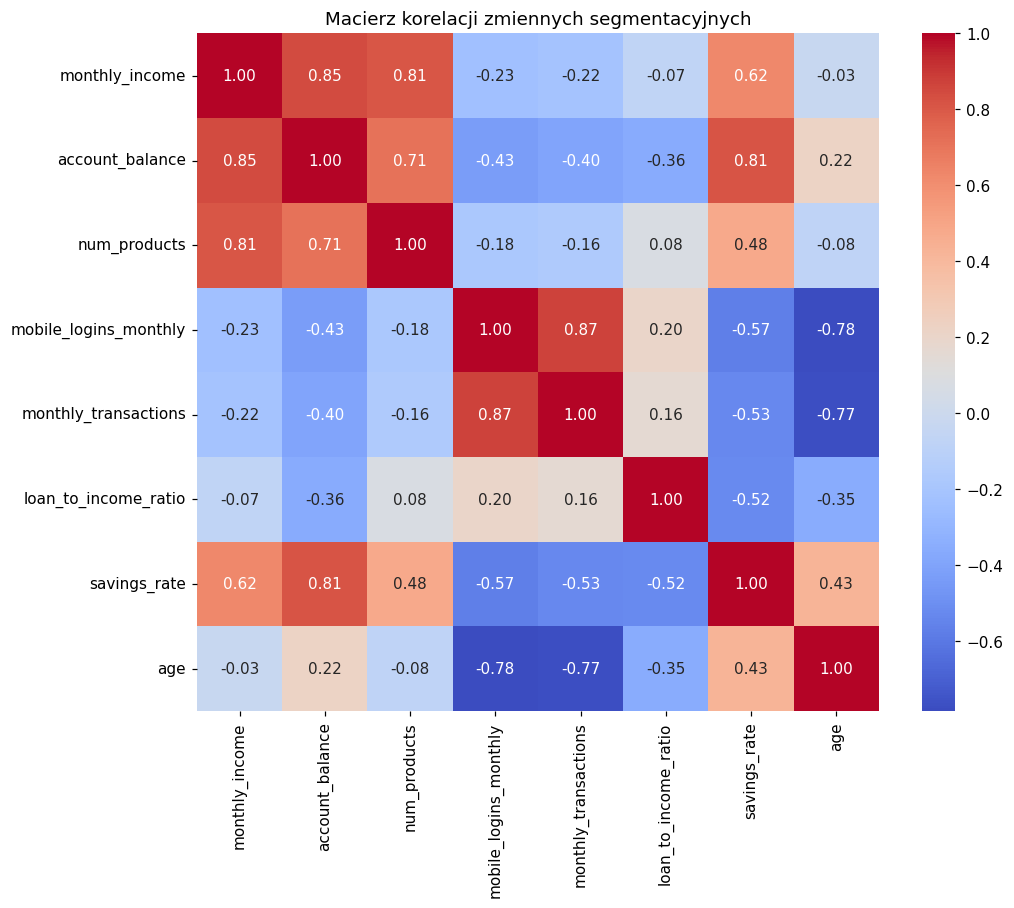

5. Standaryzacja zmiennych segmentacyjnych
Pierwsze 5 wierszy danych po standaryzacji:
   monthly_income  account_balance  num_products  mobile_logins_monthly  \
0       -0.495935        -0.425409     -0.739121              -0.861567   
1       -1.031698        -0.468933     -1.516121              -1.175816   
2       -0.554117        -0.610852     -1.516121               0.814429   
3        0.194713        -0.621518     -0.739121               0.395430   
4       -0.508056        -0.612063     -0.739121               1.128678   

   monthly_transactions  loan_to_income_ratio  savings_rate       age  
0             -0.917584             -0.749592      0.166289  0.763263  
1             -1.025941             -0.543030      1.067930  1.670848  
2              1.412100             -0.575162     -0.529543 -1.051907  
3             -0.050725              2.128512     -0.980363 -0.273977  
4              1.520457             -0.249252     -0.490341 -0.922252  
Statystyki opisowe danych po s

In [2]:
df = pd.read_csv('bank_segmentation.csv')

print("1. Struktura danych")
print("Pierwsze 5 wierszy danych:")
print(df.head())

print("Informacje o typach danych i brakach:")
print(df.info())

print("Podstawowe statystyki opisowe dla zmiennych numerycznych:")
print(df.describe().T)

print("Liczba brakujących wartości w każdej kolumnie:")
print(df.isnull().sum())

segmentation_vars = [
    'monthly_income',
    'account_balance',
    'num_products',
    'mobile_logins_monthly',
    'monthly_transactions',
    'loan_to_income_ratio',
    'savings_rate',
    'age'
]
descriptive_vars = [
    'gender',
    'city_size'
]

print(f"Wybrane zmienne do segmentacji: {segmentation_vars}")
print(f"Wybrane zmienne opisowe: {descriptive_vars}")



print("3. Statystyki opisowe i wizualizacja rozkładów zmiennych segmentacyjnych")
print("Statystyki opisowe dla zmiennych segmentacyjnych:")
print(df[segmentation_vars].describe().T)

plt.figure(figsize=(15, 10))
for i, col in enumerate(segmentation_vars):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, color=PALETTE[i % len(PALETTE)])
    plt.title(f'Rozkład zmiennej: {col}')
    plt.xlabel('')
    plt.ylabel('')
plt.tight_layout()
plt.show()


print("4. Korelacje między zmiennymi segmentacyjnymi ")
correlation_matrix = df[segmentation_vars].corr()
print("Macierz korelacji dla zmiennych segmentacyjnych:")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Macierz korelacji zmiennych segmentacyjnych')
plt.show()


print("5. Standaryzacja zmiennych segmentacyjnych")
scaler = StandardScaler()
df_scaled = df[segmentation_vars].copy()
df_scaled[segmentation_vars] = scaler.fit_transform(df[segmentation_vars])

print("Pierwsze 5 wierszy danych po standaryzacji:")
print(df_scaled.head())

print("Statystyki opisowe danych po standaryzacji (średnia bliska 0, odchylenie standardowe bliskie 1):")
print(df_scaled.describe().T)


*(monthly_income
account_balance
num_products
mobile_logins_monthly
monthly_transactions
loan_to_income_ratio
savings_rate i age, te zmienne wybralem jako zmienne kategoryzujace natomiast gender i city_size jako opisowe. Wynika to z tego, ze zmienne kategoryzujace powinny mowic nam o zachowaniach i znacznie wyrozniac poszczegolne jednostki, zeby mozna je dopasowac w grupy. Sa to w wiekszosci zmienne opisujace bezposrednia aktywnosc finansowa klientow, oprocz wieku oczywiscie, co pozowli na wyznaczenie dobrych grup. Plec i wielkosc miasta to zmienne demograficzne/metryczkowe, ktore cechuja sie mala zmiennoscia i nie mowia nam za wiele o, w tym przypadku, zachowaniach finansowych klientow. Sa one wazne, ale w przypadku grupowania uwazam, ze nie za bardzo nam pomoga, a ich uzycie mogloby dac spory szum ze wzgledu na mala zmiennosc danych)*

## Zadanie 2 - Wybor liczby segmentow i segmentacja

Wybierz dwa algorytmy - jeden z notatnika z lab a drugi ze strony scikit-learn (tu jest porównanie algorytmów: https://scikit-learn.org/stable/modules/clustering.html).
Przeprowadz segmentacje, a wyniki zwizualizuj dla konkretnego K (uzasadnij wybór K).

Zadanie 2 - Wybor liczby segmentow i segmentacja
Wybór optymalnej liczby segmentów (K) dla K-Means


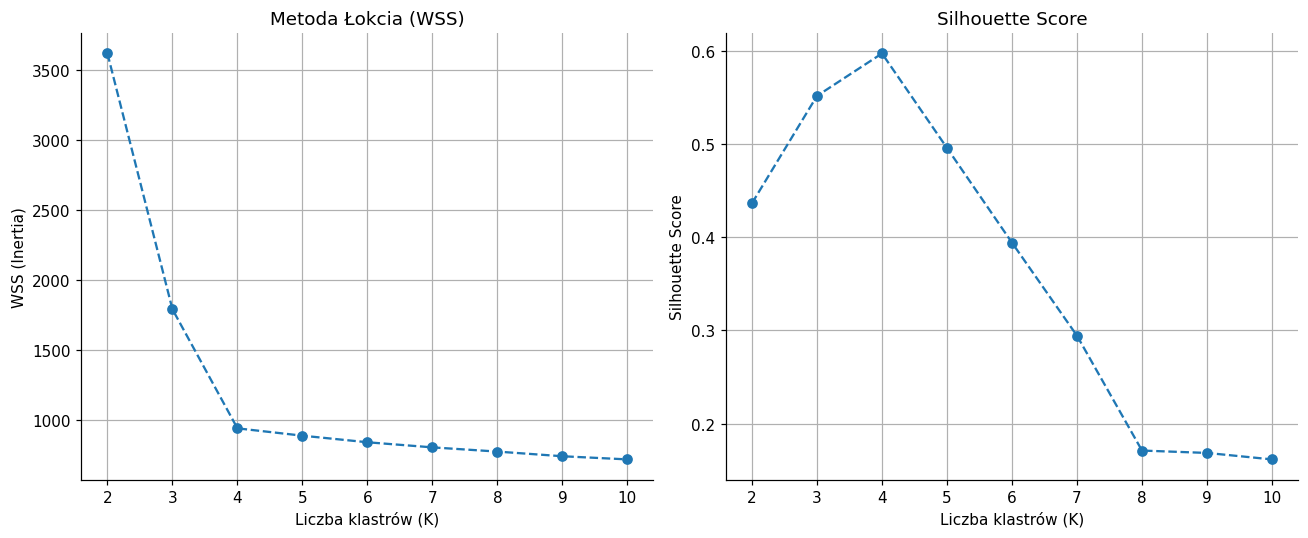

Wyniki WSS i Silhouette Score dla różnych wartości K:
         WSS  Silhouette Score
K                             
2   3617.513             0.437
3   1791.384             0.552
4    941.202             0.597
5    888.758             0.496
6    841.802             0.394
7    805.296             0.294
8    775.214             0.171
9    741.961             0.169
10   719.467             0.162

Liczba klastrów znalezionych przez Affinity Propagation: 17
Pierwsze 5 wierszy danych z przypisanymi klastrami K-Means:
   client_id cluster_kmeans
0          1              3
1          2              3
2          3              2
3          4              0
4          5              2
Pierwsze 5 wierszy danych z przypisanymi klastrami Agglomerative Clustering:
   client_id cluster_agg
0          1           2
1          2           2
2          3           3
3          4           0
4          5           3
Pierwsze 5 wierszy danych z przypisanymi klastrami Affinity Propagation:
   client_id clu

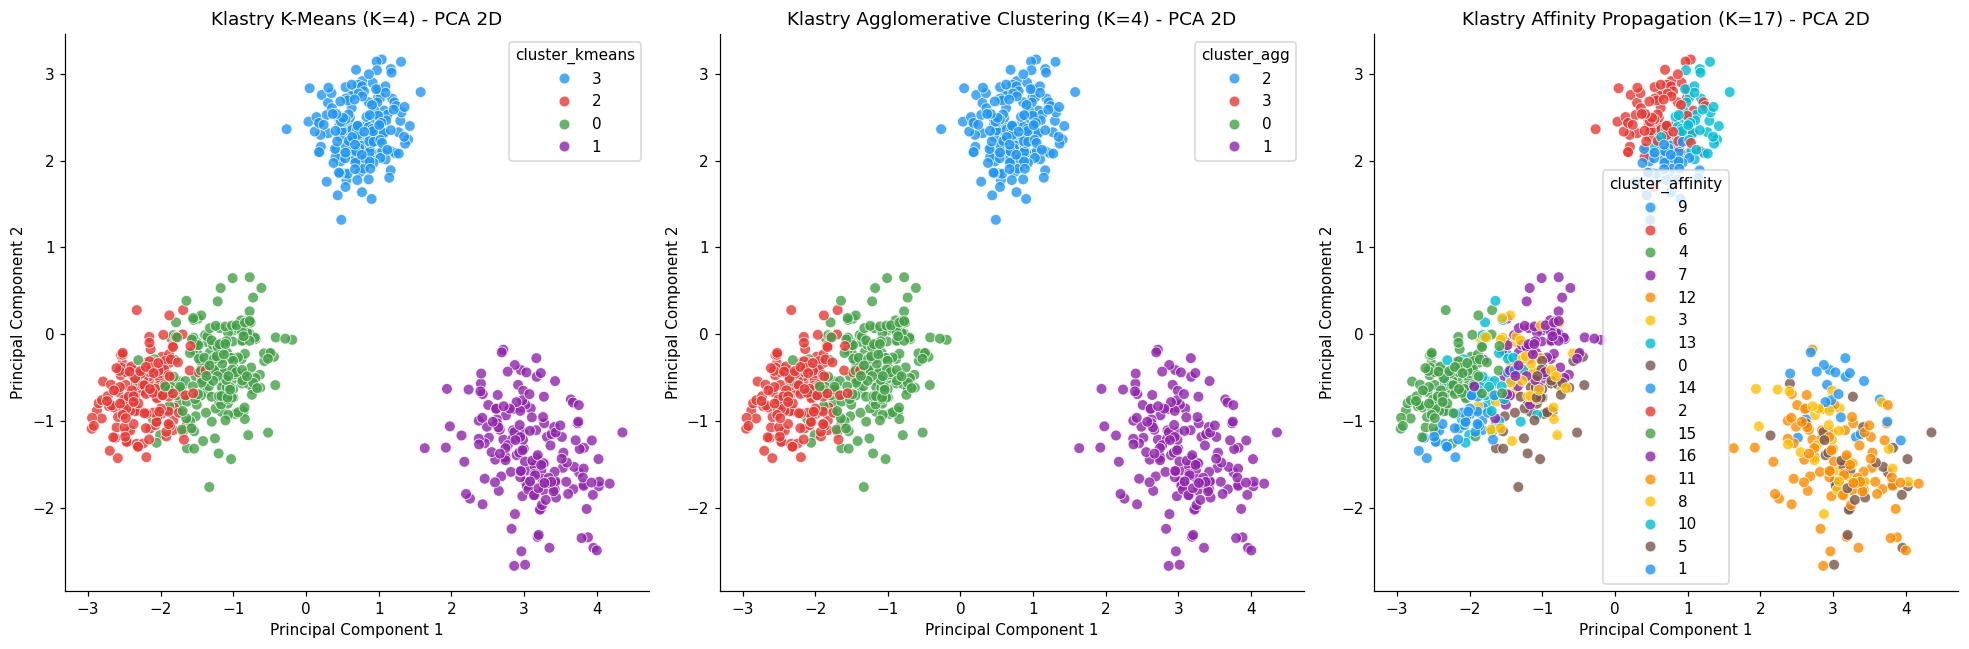

In [3]:
print("Zadanie 2 - Wybor liczby segmentow i segmentacja")

X = df_scaled.copy()

print("Wybór optymalnej liczby segmentów (K) dla K-Means")

wss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wss.append(kmeans.inertia_)

    if k > 1:
        labels = kmeans.labels_
        silhouette_scores.append(silhouette_score(X, labels))
    else:
        silhouette_scores.append(np.nan)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wss, marker='o', linestyle='--')
plt.title('Metoda Łokcia (WSS)')
plt.xlabel('Liczba klastrów (K)')
plt.ylabel('WSS (Inertia)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score')
plt.xlabel('Liczba klastrów (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

k_results = pd.DataFrame({
    'K': list(k_range),
    'WSS': wss,
    'Silhouette Score': silhouette_scores
}).set_index('K')
print("Wyniki WSS i Silhouette Score dla różnych wartości K:")
print(k_results.round(3))

optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X)

agglomerative_clustering = AgglomerativeClustering(n_clusters=optimal_k)
df['agg_cluster'] = agglomerative_clustering.fit_predict(X)

# Affinity Propagation
af = AffinityPropagation(random_state=42).fit(X)
df['affinity_cluster'] = af.labels_
n_clusters_ap = len(np.unique(af.labels_))
print(f"\nLiczba klastrów znalezionych przez Affinity Propagation: {n_clusters_ap}")

df['cluster_kmeans'] = df['kmeans_cluster'].astype(str)
df['cluster_agg'] = df['agg_cluster'].astype(str)
df['cluster_affinity'] = df['affinity_cluster'].astype(str)

print("Pierwsze 5 wierszy danych z przypisanymi klastrami K-Means:")
print(df[['client_id', 'cluster_kmeans']].head())
print("Pierwsze 5 wierszy danych z przypisanymi klastrami Agglomerative Clustering:")
print(df[['client_id', 'cluster_agg']].head())
print("Pierwsze 5 wierszy danych z przypisanymi klastrami Affinity Propagation:")
print(df[['client_id', 'cluster_affinity']].head())

print("Wizualizacja klastrów za pomocą PCA ")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_kmeans'], palette=PALETTE[:optimal_k], legend='full', s=50, alpha=0.8)
plt.title(f'Klastry K-Means (K={optimal_k}) - PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 3, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_agg'], palette=PALETTE[:optimal_k], legend='full', s=50, alpha=0.8)
plt.title(f'Klastry Agglomerative Clustering (K={optimal_k}) - PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.subplot(1, 3, 3)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster_affinity'], palette=PALETTE[:n_clusters_ap], legend='full', s=50, alpha=0.8)
plt.title(f'Klastry Affinity Propagation (K={n_clusters_ap}) - PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

*(dla algorytmu k-means wybralem ilosc klastrow 4, gdyz metoda lokciowa wskazuje nam, ze wieksza ilosc klastrow nie wyroznia, az tak bardzo naszych danych jak do 4 grup. Wskaznik silhouette przy 4ce tez jest najwzyszy co swiadczy, ze jest to prog optymalny. Affinity propagation z kolei wyznaczyl nam k = 17. W tym przypadku algorytm sam wyznacza ta ilosc klastrow, gdzie w przypadku kmeans sami na podstawie danych nam wskaznikow wss i silhouette musimy zdecydowac, ktora ilosc bedzie nam najlepiej pasowala, w przypadku tego pliku wybor jest dosc oczywisty)*

## Zadanie 3 - Profilowanie segmentow

Opisz kazdy segment na podstawie srednich zmiennych segmentacyjnych.
Uwzglednij rowniez zmienne opisowe - zbadaj czy i jak roznia sie miedzy segmentami.
Nadaj kazdemu segmentowi nazwe biznesowa i krotko uzasadnij jej wybor konkretnymi liczbami z profilu.

Zadanie 3 - Profilowanie segmentow
Profilowanie segmentów K-Means ###
Średnie wartości zmiennych segmentacyjnych dla każdego klastra K-Means (oryginalne skale):
   kmeans_cluster  monthly_income  account_balance  num_products  \
0               0         5529.13          3501.44          3.15   
1               1        12172.91         83436.79          4.79   
2               2         3828.31          2516.04          2.19   
3               3         2794.58         12168.14          1.83   

   mobile_logins_monthly  monthly_transactions  loan_to_income_ratio  \
0                  16.37                 31.45                  0.52   
1                   7.94                 17.94                  0.05   
2                  27.64                 55.15                  0.08   
3                   4.11                  9.85                  0.03   

   savings_rate    age  
0          0.04  34.83  
1          0.28  45.91  
2          0.06  26.24  
3          0.15  63.04  
Rozkład zmie

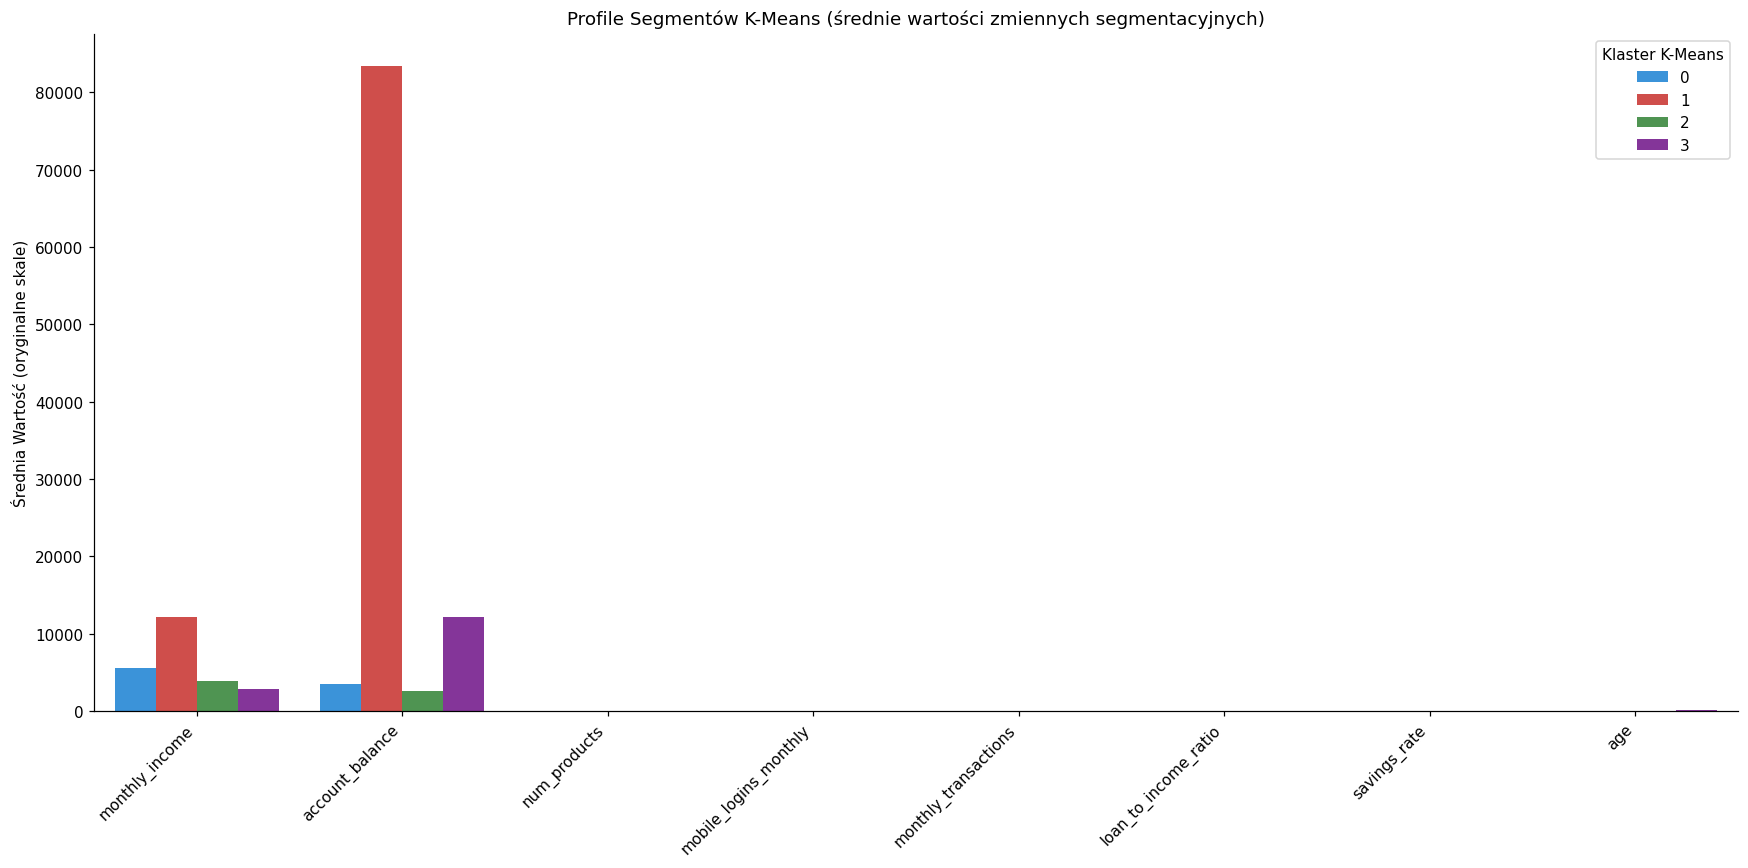

Profilowanie segmentów Agglomerative Clustering
Średnie wartości zmiennych segmentacyjnych dla każdego klastra Agglomerative Clustering (oryginalne skale):
   agg_cluster  monthly_income  account_balance  num_products  \
0            0         5529.13          3501.44          3.15   
1            1        12172.91         83436.79          4.79   
2            2         2794.58         12168.14          1.83   
3            3         3828.31          2516.04          2.19   

   mobile_logins_monthly  monthly_transactions  loan_to_income_ratio  \
0                  16.37                 31.45                  0.52   
1                   7.94                 17.94                  0.05   
2                   4.11                  9.85                  0.03   
3                  27.64                 55.15                  0.08   

   savings_rate    age  
0          0.04  34.83  
1          0.28  45.91  
2          0.15  63.04  
3          0.06  26.24  
Rozkład zmiennych opisowych (gen

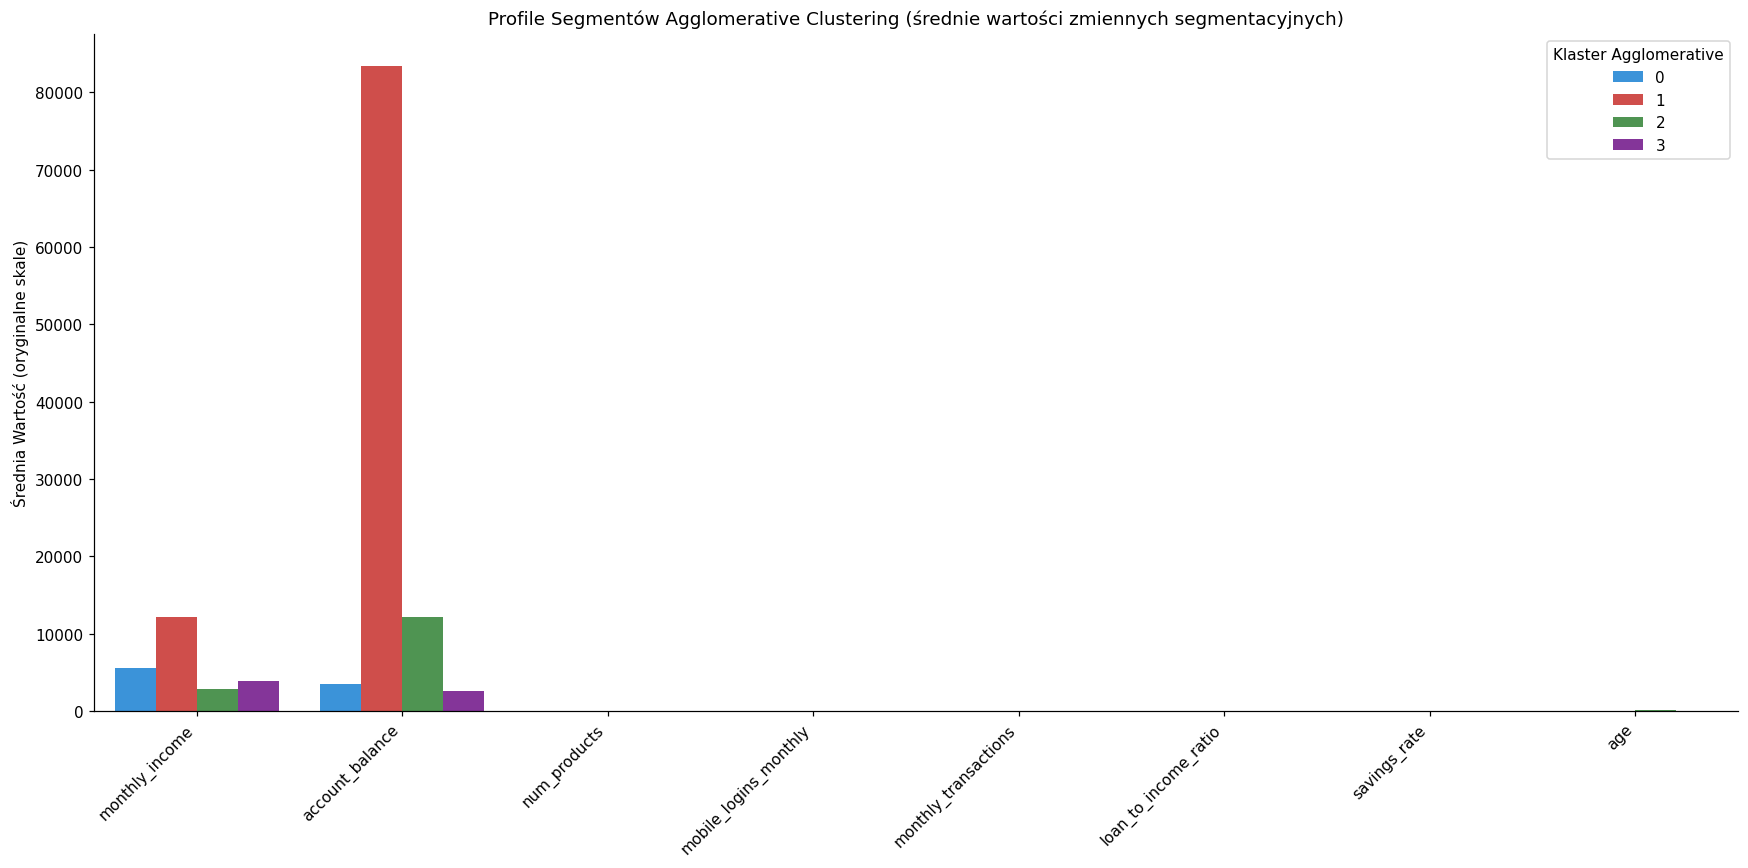

In [4]:
print("Zadanie 3 - Profilowanie segmentow")

df_clusters = df.copy()

print("Profilowanie segmentów K-Means ###")

kmeans_segment_profiles = df_clusters.groupby('kmeans_cluster')[segmentation_vars].mean().reset_index()
kmeans_segment_profiles = kmeans_segment_profiles.sort_values(by='kmeans_cluster')
print("Średnie wartości zmiennych segmentacyjnych dla każdego klastra K-Means (oryginalne skale):")
print(kmeans_segment_profiles.round(2))

print("Rozkład zmiennych opisowych (gender, city_size) dla każdego klastra K-Means:")
for var in descriptive_vars:
    print(f"Zmienna: {var}")
    print(pd.crosstab(df_clusters['kmeans_cluster'], df_clusters[var], normalize='index').round(3))


kmeans_segment_profiles_melted = kmeans_segment_profiles.melt(id_vars='kmeans_cluster',
                                                            var_name='Zmienna Segmentacyjna',
                                                            value_name='Średnia Wartość')

plt.figure(figsize=(16, 8))
sns.barplot(x='Zmienna Segmentacyjna', y='Średnia Wartość', hue='kmeans_cluster', data=kmeans_segment_profiles_melted, palette=PALETTE[:optimal_k])
plt.title('Profile Segmentów K-Means (średnie wartości zmiennych segmentacyjnych)')
plt.ylabel('Średnia Wartość (oryginalne skale)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Klaster K-Means')
plt.tight_layout()
plt.show()

print("Profilowanie segmentów Agglomerative Clustering")

agg_segment_profiles = df_clusters.groupby('agg_cluster')[segmentation_vars].mean().reset_index()
agg_segment_profiles = agg_segment_profiles.sort_values(by='agg_cluster')
print("Średnie wartości zmiennych segmentacyjnych dla każdego klastra Agglomerative Clustering (oryginalne skale):")
print(agg_segment_profiles.round(2))

print("Rozkład zmiennych opisowych (gender, city_size) dla każdego klastra Agglomerative Clustering:")
for var in descriptive_vars:
    print(f"Zmienna: {var}")
    print(pd.crosstab(df_clusters['agg_cluster'], df_clusters[var], normalize='index').round(3))

agg_segment_profiles_melted = agg_segment_profiles.melt(id_vars='agg_cluster',
                                                         var_name='Zmienna Segmentacyjna',
                                                         value_name='Średnia Wartość')

plt.figure(figsize=(16, 8))
sns.barplot(x='Zmienna Segmentacyjna', y='Średnia Wartość', hue='agg_cluster', data=agg_segment_profiles_melted, palette=PALETTE[:optimal_k])
plt.title('Profile Segmentów Agglomerative Clustering (średnie wartości zmiennych segmentacyjnych)')
plt.ylabel('Średnia Wartość (oryginalne skale)')
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Klaster Agglomerative')
plt.tight_layout()
plt.show()

*(Nazwy i opisy segmentow)*

Segment 0: Zadluzeni aktywni cyfrowo mlodzi dorosli

Klienci z umiarkowanymi dochodami (5529 PLN), ale bardzo wysokim wskaznikiem zadluzenia do dochodu (0,52) i niskimi oszczednosciami (0,04). Charakteryzuja sie wysoka aktywnoscia mobilna i transakcyjna (odpowiednio 16 logowan i 31 transakcji miesiecznie) oraz sa stosunkowo mlodzi (35 lat). Maja tez niskie saldo konta (3501 PLN).

Segment 1: Zamozni starsi inwestorzy/specjalisci

Najzamozniejsi klienci, z bardzo wysokimi dochodami (12172 PLN) i znacznie wyzszym saldem konta (83436 PLN). Posiadaja najwiecej produktow bankowych (4,79) i charakteryzuja sie bardzo wysoka stopa oszczedzania (0,28) przy bardzo niskim wskazniku zadluzenia (0,05). Sa starsi (46 lat) i mniej aktywni cyfrowo (8 logowan, 18 transakcji).

Segment 2: Aktywni cyfrowo mlodzi

Klienci (26 lat) z niskimi dochodami (3828 PLN) i bardzo niskim saldem konta (2516 PLN). Wyrozniaja sie ekstremalnie wysoka aktywnoscia mobilna (28 logowan) i transakcyjna (55 transakcji), ale maja niska stope oszczedzania (0,06) i niski wskaznik zadluzenia (0,08). Sa to mlodzi, aktywni uzytkownicy bankowosci cyfrowej, ktorzy dopiero buduja swoja pozycje finansowa i zaczynaja kariere zawodowa.

Segment 3: Stabilni finansowo seniorzy malo aktywni cyfrowo

Najstarsi klienci (63 lata) z bardzo niskimi dochodami (2794 PLN), ale umiarkowanym saldem konta (12168 PLN) i umiarkowana stopa oszczedzania (0,15). Posiadaja najmniej produktow bankowych (1,83) i sa najmniej aktywni cyfrowo i transakcyjnie (4 logowania, 10 transakcji). Maja bardzo niski wskaznik zadluzenia (0,03), co sugeruje stabilnosc finansowa, czesto niezwiązana z biezacymi dochodami.



## Zadanie 4 - Weryfikacja statystyczna i wnioski

Sprawdz czy znalezione segmenty roznia sie istotnie statystycznie.
Dobierz odpowiednie testy do typow zmiennych i uzasadnij ich wybor.
Napisz podsumowanie analizy: co odkrylas/es w danych, jakie rekomendacje produktowe mozna zaproponowac dla kazdego segmentu oraz jakie sa ograniczenia przeprowadzonej segmentacji.

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import shapiro, kruskal, mannwhitneyu, chi2_contingency

df = pd.read_csv('/content/bank_segmentation.csv')

segmentation_vars = [
    'monthly_income',
    'account_balance',
    'num_products',
    'mobile_logins_monthly',
    'monthly_transactions',
    'loan_to_income_ratio',
    'savings_rate',
    'age'
]
descriptive_vars = [
    'gender',
    'city_size'
]

scaler = StandardScaler()
df_scaled = df[segmentation_vars].copy()
df_scaled[segmentation_vars] = scaler.fit_transform(df[segmentation_vars])

X = df_scaled.copy()
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans_final.fit_predict(X)

print("Zadanie 4 - Weryfikacja statystyczna i wnioski\n")

print("Weryfikacja statystyczna różnic między segmentami K-Means ")


print("Testy dla zmiennych segmentacyjnych (numeryczne): ANOVA / Kruskal-Wallis ")
print("H0 dla Kruskala-Wallisa: Wszystkie segmenty mają identyczny rozkład cechy.")
print("H1 dla Kruskala-Wallisa: Co najmniej jeden segment różni się.")


alpha = 0.05
num_kmeans_clusters = df['kmeans_cluster'].nunique()

for var in segmentation_vars:
    groups = [df[df['kmeans_cluster'] == c][var] for c in sorted(df['kmeans_cluster'].unique())]


    normal_assumption_met = True
    for group in groups:
        if len(group) > 3:
            stat, p = shapiro(group)
            if p < alpha:
                normal_assumption_met = False
                break
        else:
            normal_assumption_met = False

    if normal_assumption_met:

        f_stat, p_value_anova = stats.f_oneway(*groups)
        print(f"Zmienna '{var}': Test ANOVA")
        print(f"  F-statystyka = {f_stat:.3f}, p-wartość = {p_value_anova:.3f}")
        if p_value_anova < alpha:
            print("  -> Istotne statystycznie różnice między średnimi segmentów (odrzucono H0).")
        else:
            print("  -> Brak istotnych statystycznie różnic między średnimi segmentów (nie odrzucono H0).")
    else:

        h_stat, p_value_kruskal = kruskal(*groups)
        print(f"Zmienna '{var}': Test Kruskala-Wallisa")
        print(f"  H-statystyka = {h_stat:.3f}, p-wartość = {p_value_kruskal:.3f}")
        if p_value_kruskal < alpha:
            print("  -> Istotne statystycznie różnice między medianami segmentów (odrzucono H0).")

            print("  Przeprowadzanie testów post-hoc Mann-Whitney U z korekcją Bonferroniego:")


            num_comparisons = num_kmeans_clusters * (num_kmeans_clusters - 1) / 2
            if num_comparisons == 0:
                bonferroni_alpha = alpha
            else:
                bonferroni_alpha = alpha / num_comparisons

            segment_ids = sorted(df['kmeans_cluster'].unique())

            for i, cluster1 in enumerate(segment_ids):
                for j, cluster2 in enumerate(segment_ids):
                    if j <= i: #
                        continue

                    group1 = df[df['kmeans_cluster'] == cluster1][var]
                    group2 = df[df['kmeans_cluster'] == cluster2][var]


                    if len(group1) > 0 and len(group2) > 0:
                        stat, p = mannwhitneyu(group1, group2, alternative='two-sided')
                        print(f"    - Para {cluster1} vs {cluster2}: p-wartość = {p:.3f}")
                        if p < bonferroni_alpha:
                            print(f"      -> Istotna statystycznie różnica (p < {bonferroni_alpha:.3f} po korekcji Bonferroniego)")
                        else:
                            print(f"      -> Brak istotnej statystycznie różnicy (p >= {bonferroni_alpha:.3f} po korekcji Bonferroniego)")
                    else:
                        print(f"    - Para {cluster1} vs {cluster2}: Brak wystarczających danych w jednej z grup do przeprowadzenia testu.")
        else:
            print("  -> Brak istotnych statystycznie różnic między medianami segmentów (nie odrzucono H0).")



print("Testy dla zmiennych opisowych (kategoryczne): Test Chi-kwadrat ")
print("H0 dla Chi-kwadrat: Zmienne są niezależne (brak związku między przynależnością do segmentu a zmienną opisową).")
print("H1 dla Chi-kwadrat: Zmienne są zależne (istnieje związek).")


for var in descriptive_vars:
    contingency_table = pd.crosstab(df['kmeans_cluster'], df[var])
    chi2_stat, p_value_chi2, dof, expected = chi2_contingency(contingency_table)
    print(f"Zmienna '{var}': Test Chi-kwadrat")
    print(f"  Statystyka Chi2 = {chi2_stat:.3f}, p-wartość = {p_value_chi2:.3f}")
    if p_value_chi2 < alpha:
        print("  -> Istotny statystycznie związek między zmienną a przynależnością do segmentu (odrzucono H0).")
    else:
        print("  -> Brak istotnego statystycznie związku między zmienną a przynależnością do segmentu (nie odrzucono H0).")

Zadanie 4 - Weryfikacja statystyczna i wnioski

Weryfikacja statystyczna różnic między segmentami K-Means 
Testy dla zmiennych segmentacyjnych (numeryczne): ANOVA / Kruskal-Wallis 
H0 dla Kruskala-Wallisa: Wszystkie segmenty mają identyczny rozkład cechy.
H1 dla Kruskala-Wallisa: Co najmniej jeden segment różni się.
Zmienna 'monthly_income': Test ANOVA
  F-statystyka = 2333.282, p-wartość = 0.000
  -> Istotne statystycznie różnice między średnimi segmentów (odrzucono H0).
Zmienna 'account_balance': Test ANOVA
  F-statystyka = 3313.660, p-wartość = 0.000
  -> Istotne statystycznie różnice między średnimi segmentów (odrzucono H0).
Zmienna 'num_products': Test Kruskala-Wallisa
  H-statystyka = 581.902, p-wartość = 0.000
  -> Istotne statystycznie różnice między medianami segmentów (odrzucono H0).
  Przeprowadzanie testów post-hoc Mann-Whitney U z korekcją Bonferroniego:
    - Para 0 vs 1: p-wartość = 0.000
      -> Istotna statystycznie różnica (p < 0.008 po korekcji Bonferroniego)
    - 


Wybralem test ANOVA do zbadania czy srednie, danych zmiennych, pomiedzy grupami roznia sie istotnie statystycznie, pozwala on na porownanie kilku sredni z roznych grup naraz, jednak ma problem z "nieladnymi" danymi czyli kiedy np. nie ma normalnego rozkladu czy rozklady sa skosne, dlatego postanowilem uzyc tez testu Kruskala-Wallisa, ktory pozwala sprawdzic czy takie problematyczne dane roznia sie pomiedzy grupami. Dla zmiennych opisowych wybralem Test chi-kwadrat ktory bada niezaleznosc zmiennych i jest w stanie nam powiedziec czy jest zaleznosc pomiedzy zmienna a danym segmentem

W kazdym z analizowanych przypadkow odrzucam hipoteze zerowa, co oznacza, ze segmenty roznia sie istotnie statystycznie pod wzgledem analizowanych zmiennych finansowych i behawioralnych. Oznacza to, ze wyodrebnione segmenty reprezentuja odmienne profile klientow. Dodatkowo przeprowadzono testy post-hoc Mann-Whitney U z korekcja Bonferroniego, ktore wykazaly istotne statystycznie roznice pomiedzy wszystkimi parami segmentow. Wskazuje to, ze kazda z wyodrebnionych grup klientow charakteryzuje sie odmiennym poziomem analizowanych cech

Dla zmiennych opisowych zastosowano test Chi-kwadrat niezaleznosci, ktory pozwala sprawdzic czy istnieje zwiazek pomiedzy przynaleznoscia do segmentu a zmienna kategoryczna. W przypadku zmiennej gender uzyskano p = 0.661, natomiast dla zmiennej city_size p = 0.134. W obu przypadkach nie odrzucono hipotezy zerowej, co oznacza brak istotnego statystycznie zwiazku pomiedzy plecia oraz wielkoscia miasta a przynaleznoscia do segmentu. Oznacza to, ze zmienne te nie roznicuja istotnie wyodrebnionych grup klientow

Segment 0 obejmuje zadluzonych, aktywnych cyfrowo mlodych doroslych. W przypadku tej grupy odpowiednie moga byc produkty wspierajace zarzadzanie zadluzeniem oraz codziennymi finansami. Do potencjalnych rekomendacji naleza konsolidacja kredytow, kredyty ratalne lub limit w koncie, narzedzia do zarzadzania budzetem, programy edukacji finansowej oraz produkty pomagajace stopniowo budowac oszczednosci

Segment 1 stanowi grupa zamoznych starszych inwestorow/specjalistow. Dla tych klientow najbardziej odpowiednie beda produkty inwestycyjne oraz rozwiazania z zakresu zarzadzania majatkiem. W szczegolnosci mozna zaproponowac fundusze inwestycyjne, doradztwo typu wealth management, produkty emerytalne, a takze oferty premium i uslugi private banking

Segment 2 obejmuje mlodych intensywnych uzytkownikow bankowosci cyfrowej. Sa to osoby o relatywnie nizszych dochodach, ale bardzo wysokiej aktywnosci mobilnej i transakcyjnej. W ich przypadku odpowiednie beda mobilne produkty bankowe, szybkie platnosci i rozwiazania fintechowe, mikrokredyty oraz konta studenckie i mlodziezowe

Segment 3 obejmuje stabilnych finansowo seniorow o niskiej aktywnosci cyfrowej. W przypadku tej grupy klientow odpowiednie beda przede wszystkim bezpieczne produkty oszczednosciowe oraz rozwiazania dopasowane do nizszej aktywnosci cyfrowej, takie jak lokaty bankowe, produkty emerytalne, uproszczone produkty bankowe oraz wsparcie w korzystaniu z bankowosci elektronicznej

Teraz o ograniczeniach seegmentacji slow kilka. Segmentacja zostala wykonana przy uzyciu algorytmu kmeans, ktory zaklada istnienie kulistych klastrow oraz jest wrazliwy na skalowanie zmiennych i wartosci odstajace. W analizie wykorzystano ograniczony zestaw zmiennych, glownie finansowych i behawioralnych, co moze ograniczac interpretacje uzyskanych segmentow. Dodatkowo analiza ma charakter statyczny i opiera sie na danych z jednego okresu czasu, podczas gdy zachowania finansowe klientow moga zmieniac sie wraz z cyklem zycia lub zmiana sytuacji ekonomicznej